<a href="https://colab.research.google.com/github/avionerman/AML/blob/main/rf_drones_w_focal_and_cost_sens_impl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup

In [1]:
!pip install -q torch torchvision scikit-learn matplotlib seaborn onnx onnxruntime
!pip install -q onnxscript


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 130.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 23.3 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import torch

assert torch.cuda.is_available(), (
    "No GPU detected."
)

DEVICE = torch.device("cuda")
props = torch.cuda.get_device_properties(0)

print(f"PyTorch version : {torch.__version__}")
print(f"GPU             : {props.name}")
print(f"GPU memory      : {props.total_memory / 1e9:.1f} GB")

PyTorch version : 2.10.0+cu128
GPU             : NVIDIA A100-SXM4-80GB
GPU memory      : 85.1 GB


In [4]:
from pathlib import Path

DRIVE_ROOT = Path("/content/drive/MyDrive/rf_drones")
DATA_PATH  = DRIVE_ROOT / "small_dataset" / "dataset2.pt"

OUT_DIR    = DRIVE_ROOT / "outputs3"
CKPT_DIR   = OUT_DIR / "checkpoints3"
SPLITS_DIR = OUT_DIR / "splits3"
FIG_DIR    = OUT_DIR / "figures3"

for d in (OUT_DIR, CKPT_DIR, SPLITS_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

assert DATA_PATH.exists(), (
    f"Dataset not found at {DATA_PATH}. "
    f"Upload dataset.pt to MyDrive/rf_drones/small_dataset/ and re-run this cell."
)

print(f"Dataset    : {DATA_PATH}  ({DATA_PATH.stat().st_size / 1e9:.1f} GB)")
print(f"Output dir : {OUT_DIR}")

Dataset    : /content/drive/MyDrive/rf_drones/small_dataset/dataset2.pt  (12.9 GB)
Output dir : /content/drive/MyDrive/rf_drones/outputs3


# 1. Configuration

In [61]:
import random
import numpy as np
import torch

# ─────────────────────────────────────────────────────────────────
# Class registry (following the original dt order)
# ─────────────────────────────────────────────────────────────────
CLASS_NAMES = {
    0: "DJI",
    1: "FutabaT14",
    2: "FutabaT7",
    3: "Graupner",
    4: "Noise",
    5: "Taranis",
    6: "Turnigy",
}
NUM_CLASSES  = len(CLASS_NAMES)
NOISE_IDX    = 4
FRIENDLY_IDX = [i for i in CLASS_NAMES if i != NOISE_IDX]   # [0, 1, 2, 3, 5, 6]

SAMPLING_RATE_HZ = 14_000_000
SEED = 42

# ─────────────────────────────────────────────────────────────────
# Data subsampling (1.0 = 100%)
# ─────────────────────────────────────────────────────────────────
SUBSAMPLE_FRAC = 1.0

# ─────────────────────────────────────────────────────────────────
# Split ratios — pinned by scope.txt, do not change
# ─────────────────────────────────────────────────────────────────
TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
TEST_FRAC  = 0.15

# ─────────────────────────────────────────────────────────────────
# DataLoader
# pin memory -> transfers to GPU async & faster
# ─────────────────────────────────────────────────────────────────
BATCH_SIZE  = 128
NUM_WORKERS = 2
PIN_MEMORY  = True

# ─────────────────────────────────────────────────────────────────
# Augmentation strengths (train split only)
# ─────────────────────────────────────────────────────────────────
AUG_TIME_SHIFT_FRAC       = 0.10   # ±10% of 128 columns, circular
AUG_GAUSS_NOISE_SIGMA_MAX = 0.10   # σ ~ U(0, 0.10) post-normalisation
AUG_SPECAUG_TIME_MASK     = 16     # max columns masked
AUG_SPECAUG_FREQ_MASK     = 16     # max rows masked

# ─────────────────────────────────────────────────────────────────
# Optimiser / scheduler / training loop
# ─────────────────────────────────────────────────────────────────
EPOCHS              = 30
LEARNING_RATE       = 1e-3
WEIGHT_DECAY        = 1e-4
WARMUP_EPOCHS       = 3
EARLY_STOP_PATIENCE = 5
USE_AMP             = True

# ─────────────────────────────────────────────────────────────────
# Friend/foe gate (OOD calibration)
# ─────────────────────────────────────────────────────────────────
OOD_TARGET_FALSE_FOE_RATE = 0.01   # ≤1% of known-drone val samples flagged as foe

# ─────────────────────────────────────────────────────────────────
# Seed everything for reproducibility
# ─────────────────────────────────────────────────────────────────
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print(f"Classes         : {list(CLASS_NAMES.values())}")
print(f"Friendly        : {[CLASS_NAMES[i] for i in FRIENDLY_IDX]}")
print(f"Foe (background): {CLASS_NAMES[NOISE_IDX]}")
print(f"Subsample       : {SUBSAMPLE_FRAC:.0%}")
print(f"Batch size      : {BATCH_SIZE}")
print(f"Epochs          : {EPOCHS} (warmup {WARMUP_EPOCHS}, patience {EARLY_STOP_PATIENCE})")
print(f"AMP             : {USE_AMP}")

Classes         : ['DJI', 'FutabaT14', 'FutabaT7', 'Graupner', 'Noise', 'Taranis', 'Turnigy']
Friendly        : ['DJI', 'FutabaT14', 'FutabaT7', 'Graupner', 'Taranis', 'Turnigy']
Foe (background): Noise
Subsample       : 100%
Batch size      : 128
Epochs          : 30 (warmup 3, patience 5)
AMP             : True


# 2. Load dataset

In [62]:
import gc
import time
import torch

# Idempotent: skip the reload if tensors are already in this kernel.
if isinstance(globals().get("x_spec"), torch.Tensor):
    print(f"x_spec already loaded ({tuple(x_spec.shape)}). Skipping reload.")
else:
    print(f"Loading {DATA_PATH}")
    print(f"  (~25 GB over Drive FUSE — expect 10–25 min the first time per session)")
    t0 = time.time()
    _data = torch.load(DATA_PATH, map_location="cpu", weights_only=False)
    print(f"  torch.load completed in {(time.time() - t0) / 60:.1f} min")

    # Extract only what this notebook uses. Reference assignments — no copy.
    x_spec     = _data["x_spec"]      # (N, 2, 128, 128) float32  — model input
    y          = _data["y"]           # (N,)              int64    — class label
    snr        = _data["snr"]         # (N,)              int32    — SNR in dB
    duty_cycle = _data["duty_cycle"]  # (N,)              float32  — fraction of window with TX

    # Drop _data — releases the only remaining reference to x_iq (~13 GB).
    del _data
    gc.collect()
    print(f"  x_iq dropped (~13 GB freed)")

spec_gb = x_spec.element_size() * x_spec.nelement() / 1e9
print()
print(f"x_spec     : {tuple(x_spec.shape)}  {x_spec.dtype}  ({spec_gb:.2f} GB in RAM)")
print(f"y          : {tuple(y.shape)}            {y.dtype}")
print(f"snr        : {tuple(snr.shape)}            {snr.dtype}    range [{int(snr.min())}, {int(snr.max())}] dB")
print(f"duty_cycle : {tuple(duty_cycle.shape)}            {duty_cycle.dtype}  range [{duty_cycle.min():.2f}, {duty_cycle.max():.2f}]")

x_spec already loaded ((98705, 2, 128, 128)). Skipping reload.

x_spec     : (98705, 2, 128, 128)  torch.float32  (12.94 GB in RAM)
y          : (98705,)            torch.int64
snr        : (98705,)            torch.int32    range [-20, 30] dB
duty_cycle : (98705,)            torch.float32  range [0.00, 1.00]


In [63]:
# Optional: in case we need to run a subsample of the dataset
# and we need to equaly represent each class in the respective sample
# stratified random subsample instead of just random

import numpy as np
from sklearn.model_selection import train_test_split

if SUBSAMPLE_FRAC < 1.0:
    n_before = len(y)
    composite_key = y.numpy().astype(np.int64) * 100 + snr.numpy().astype(np.int64)
    all_idx = np.arange(n_before)

    keep_idx, _ = train_test_split(
        all_idx,
        train_size=SUBSAMPLE_FRAC,
        stratify=composite_key,
        random_state=SEED,
    )
    keep_idx = torch.from_numpy(np.sort(keep_idx))

    x_spec     = x_spec.index_select(0, keep_idx).contiguous()
    y          = y.index_select(0, keep_idx).contiguous()
    snr        = snr.index_select(0, keep_idx).contiguous()
    duty_cycle = duty_cycle.index_select(0, keep_idx).contiguous()

    gc.collect()
    spec_gb = x_spec.element_size() * x_spec.nelement() / 1e9
    print(f"Subsampled: {n_before:,} → {len(y):,} samples ({SUBSAMPLE_FRAC:.0%})")
    print(f"x_spec now : {tuple(x_spec.shape)}  ({spec_gb:.2f} GB in RAM)")
else:
    print(f"SUBSAMPLE_FRAC = {SUBSAMPLE_FRAC} — using full dataset ({len(y):,} samples).")

SUBSAMPLE_FRAC = 1.0 — using full dataset (98,705 samples).


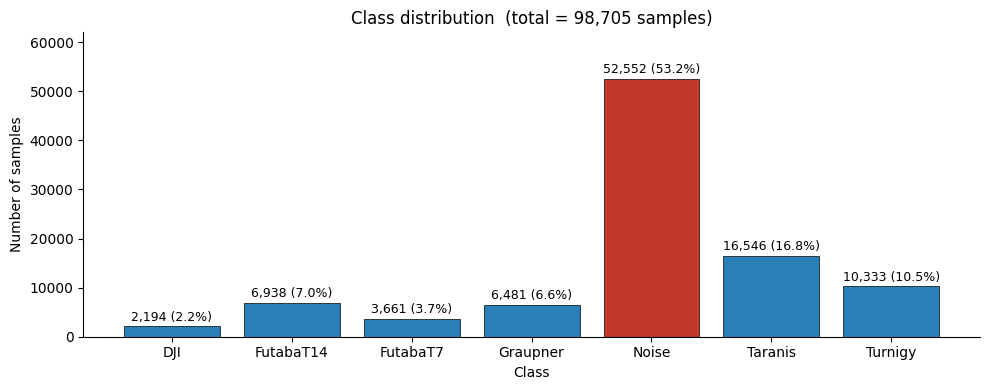

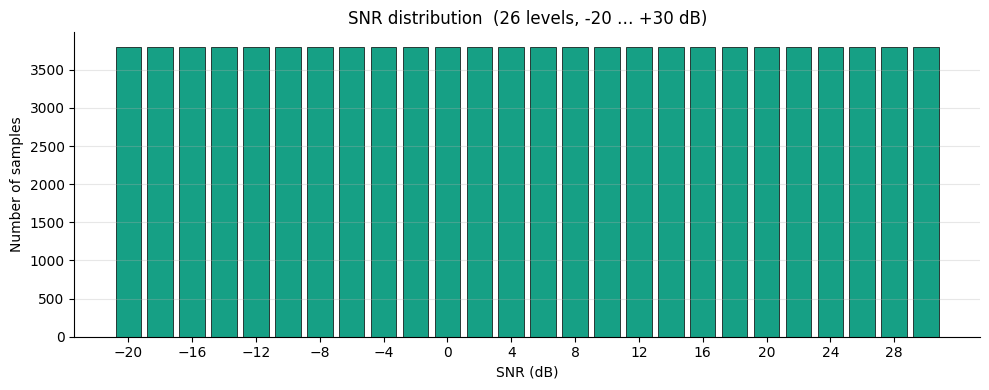

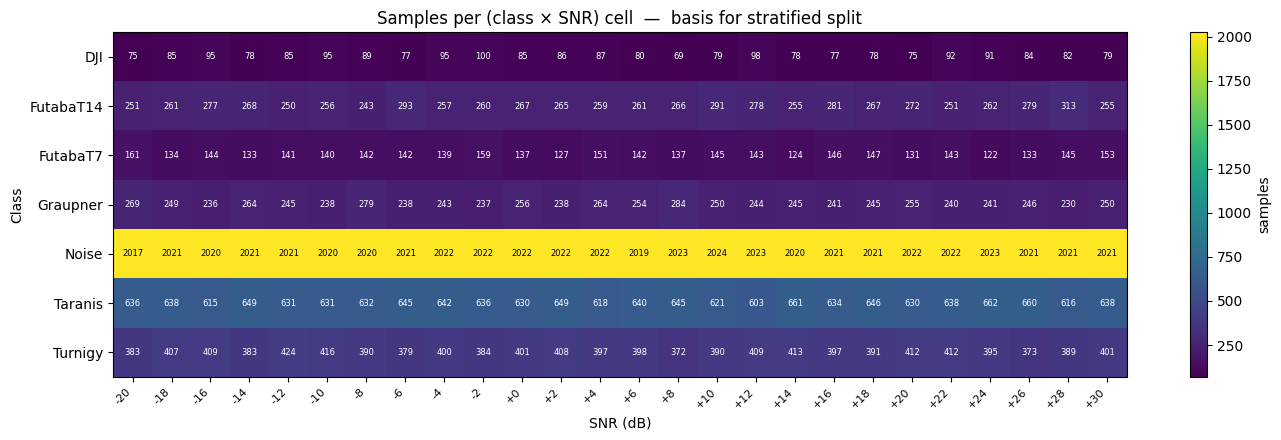

Class imbalance ratio (max/min): 24.0x
Duty cycle                     : mean 0.291, median 0.000
(class × SNR) cells            : 182  (182 non-empty)
Smallest non-empty cell        : 69 samples
Largest cell                   : 2024 samples (Noise at +10 dB)
Figures saved                  : /content/drive/MyDrive/rf_drones/outputs3/figures3


In [64]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# ─────────────────────────────────────────────────────────────────
# 1) Class histogram — Noise (foe) coloured red, friendlies blue
# ─────────────────────────────────────────────────────────────────
class_counts = Counter(y.tolist())
total = sum(class_counts.values())
class_idx   = sorted(class_counts)
class_names = [CLASS_NAMES.get(i, f"unknown({i})") for i in class_idx]
class_n     = [class_counts[i] for i in class_idx]
class_pct   = [100.0 * n / total for n in class_n]
class_clrs  = ["#c0392b" if i == NOISE_IDX else "#2980b9" for i in class_idx]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(class_names, class_n, color=class_clrs, edgecolor="black", linewidth=0.5)
for bar, n, pct in zip(bars, class_n, class_pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.005,
            f"{n:,} ({pct:.1f}%)", ha="center", va="bottom", fontsize=9)
ax.set_title(f"Class distribution  (total = {total:,} samples)")
ax.set_xlabel("Class")
ax.set_ylabel("Number of samples")
ax.set_ylim(0, max(class_n) * 1.18)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "class_distribution.png", dpi=120)
plt.show()

# ─────────────────────────────────────────────────────────────────
# 2) SNR histogram — should be roughly flat across all 26 levels
# ─────────────────────────────────────────────────────────────────
snr_counts = Counter(int(s) for s in snr.tolist())
snrs_sorted = sorted(snr_counts)
snr_n       = [snr_counts[s] for s in snrs_sorted]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(snrs_sorted, snr_n, color="#16a085", edgecolor="black", linewidth=0.5, width=1.6)
ax.set_title(f"SNR distribution  ({len(snr_counts)} levels, {snrs_sorted[0]:+d} … {snrs_sorted[-1]:+d} dB)")
ax.set_xlabel("SNR (dB)")
ax.set_ylabel("Number of samples")
ax.set_xticks(snrs_sorted[::2])
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "snr_distribution.png", dpi=120)
plt.show()

# ─────────────────────────────────────────────────────────────────
# 3) Class × SNR heatmap — joint distribution, basis for stratified split
# ─────────────────────────────────────────────────────────────────
classes_sorted = sorted(set(y.tolist()))
cls_to_row     = {c: i for i, c in enumerate(classes_sorted)}
snr_to_col     = {s: i for i, s in enumerate(snrs_sorted)}

pair_counts = Counter(zip(y.tolist(), [int(s) for s in snr.tolist()]))
matrix = np.zeros((len(classes_sorted), len(snrs_sorted)), dtype=int)
for (cls, s), n in pair_counts.items():
    matrix[cls_to_row[cls], snr_to_col[s]] = n

fig, ax = plt.subplots(figsize=(14, 4.5))
im = ax.imshow(matrix, aspect="auto", cmap="viridis")
ax.set_yticks(range(len(classes_sorted)))
ax.set_yticklabels([CLASS_NAMES[c] for c in classes_sorted])
ax.set_xticks(range(len(snrs_sorted)))
ax.set_xticklabels([f"{s:+d}" for s in snrs_sorted], rotation=45, ha="right", fontsize=8)
ax.set_xlabel("SNR (dB)")
ax.set_ylabel("Class")
ax.set_title("Samples per (class × SNR) cell  —  basis for stratified split")

vmax = matrix.max() or 1
for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        v = matrix[i, j]
        color = "white" if v < vmax * 0.5 else "black"
        ax.text(j, i, f"{v}", ha="center", va="center", fontsize=6, color=color)

fig.colorbar(im, ax=ax, label="samples")
plt.tight_layout()
plt.savefig(FIG_DIR / "class_snr_heatmap.png", dpi=120)
plt.show()

# ─────────────────────────────────────────────────────────────────
# Numeric summary
# ─────────────────────────────────────────────────────────────────
imbalance = max(class_counts.values()) / min(class_counts.values())
nonzero   = matrix[matrix > 0]
argmax_flat = matrix.argmax()
max_cls = CLASS_NAMES[classes_sorted[argmax_flat // matrix.shape[1]]]
max_snr = snrs_sorted[argmax_flat % matrix.shape[1]]
print(f"Class imbalance ratio (max/min): {imbalance:.1f}x")
print(f"Duty cycle                     : mean {duty_cycle.mean():.3f}, median {duty_cycle.median():.3f}")
print(f"(class × SNR) cells            : {matrix.size}  ({len(nonzero)} non-empty)")
print(f"Smallest non-empty cell        : {nonzero.min()} samples")
print(f"Largest cell                   : {matrix.max()} samples ({max_cls} at {max_snr:+d} dB)")
print(f"Figures saved                  : {FIG_DIR}")

# 3. Stratified & 70/15/15 split

In [65]:
# Building and split

import numpy as np
from sklearn.model_selection import train_test_split

train_path = SPLITS_DIR / "train3.npy"
val_path   = SPLITS_DIR / "val3.npy"
test_path  = SPLITS_DIR / "test3.npy"

if all(p.exists() for p in (train_path, val_path, test_path)):
    train_idx = np.load(train_path)
    val_idx   = np.load(val_path)
    test_idx  = np.load(test_path)
    print(f"Loaded existing splits from {SPLITS_DIR}")
else:
    n = len(y)
    composite_key = y.numpy().astype(np.int64) * 100 + snr.numpy().astype(np.int64)
    all_idx = np.arange(n)

    # Step 1: train (70%) vs holdout (30%), stratified on (class, SNR).
    train_idx, hold_idx = train_test_split(
        all_idx,
        train_size=TRAIN_FRAC,
        stratify=composite_key,
        random_state=SEED,
    )

    # Step 2: split the 30% holdout in half — val (15%) and test (15%).
    val_idx, test_idx = train_test_split(
        hold_idx,
        train_size=VAL_FRAC / (VAL_FRAC + TEST_FRAC),  # 0.5
        stratify=composite_key[hold_idx],
        random_state=SEED,
    )

    train_idx = np.sort(train_idx)
    val_idx   = np.sort(val_idx)
    test_idx  = np.sort(test_idx)

    np.save(train_path, train_idx)
    np.save(val_path,   val_idx)
    np.save(test_path,  test_idx)
    print(f"Computed and saved new splits to {SPLITS_DIR}")

n = len(y)
print()
print(f"Total : {n:,}")
print(f"  Train : {len(train_idx):>7,}  ({100 * len(train_idx) / n:5.2f}%)")
print(f"  Val   : {len(val_idx):>7,}  ({100 * len(val_idx) / n:5.2f}%)")
print(f"  Test  : {len(test_idx):>7,}  ({100 * len(test_idx) / n:5.2f}%)")

Loaded existing splits from /content/drive/MyDrive/rf_drones/outputs3/splits3

Total : 98,705
  Train :  69,093  (70.00%)
  Val   :  14,806  (15.00%)
  Test  :  14,806  (15.00%)


Coverage OK : all 182 (class × SNR) cells present in train, val, AND test

Class           Full %   Train %     Val %    Test %   Max drift
----------------------------------------------------------------
DJI              2.22%     2.23%     2.22%     2.20%      0.028%
FutabaT14        7.03%     7.03%     7.04%     7.02%      0.009%
FutabaT7         3.71%     3.71%     3.73%     3.69%      0.019%
Graupner         6.57%     6.57%     6.56%     6.57%      0.006%
Noise           53.24%    53.24%    53.21%    53.27%      0.027%
Taranis         16.76%    16.76%    16.78%    16.75%      0.021%
Turnigy         10.47%    10.47%    10.45%    10.50%      0.027%


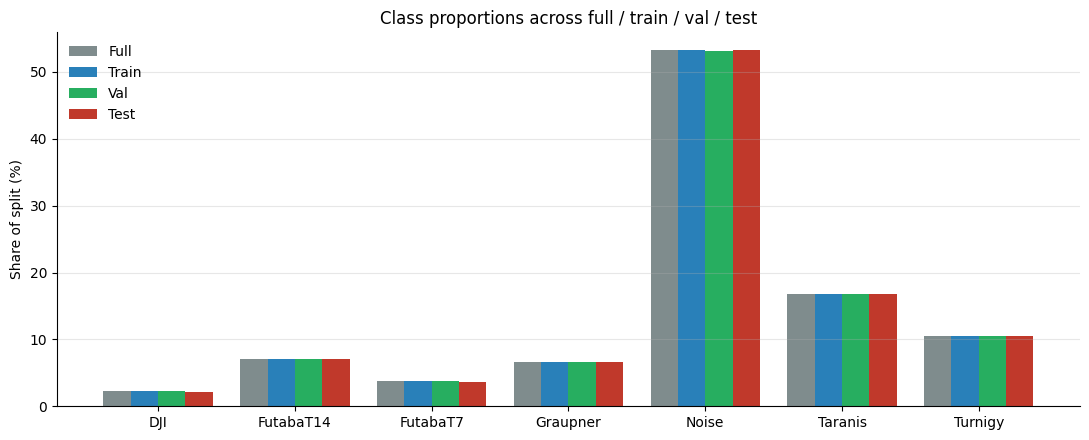


Saved figure: /content/drive/MyDrive/rf_drones/outputs3/figures3/split_class_proportions.png


In [66]:
# Checking the coverage and the proportion drift among the classes

import matplotlib.pyplot as plt
from collections import Counter

splits = {"train": train_idx, "val": val_idx, "test": test_idx}

# Check 1: every (class x SNR) cell present in every split
full_cells = set(zip(y.tolist(), [int(s) for s in snr.tolist()]))
issues = []
for name, idx in splits.items():
    cells = set(zip(y[idx].tolist(), [int(s) for s in snr[idx].tolist()]))
    missing = full_cells - cells
    if missing:
        issues.append(f"{name}: {len(missing)} cell(s) missing — {sorted(missing)[:3]}...")

if issues:
    print("WARNING: stratification issues")
    for i in issues:
        print(f"  {i}")
else:
    print(f"Coverage OK : all {len(full_cells)} (class × SNR) cells present in train, val, AND test")

# Check 2: class proportion drift
full_cls = Counter(y.tolist())
print()
header = f"{'Class':<12}{'Full %':>10}{'Train %':>10}{'Val %':>10}{'Test %':>10}{'Max drift':>12}"
print(header)
print("-" * len(header))
rows = []
for c in sorted(full_cls):
    full_pct  = 100 * full_cls[c] / len(y)
    train_pct = 100 * (y[train_idx] == c).sum().item() / len(train_idx)
    val_pct   = 100 * (y[val_idx]   == c).sum().item() / len(val_idx)
    test_pct  = 100 * (y[test_idx]  == c).sum().item() / len(test_idx)
    drift = max(abs(p - full_pct) for p in (train_pct, val_pct, test_pct))
    print(f"{CLASS_NAMES[c]:<12}{full_pct:>9.2f}%{train_pct:>9.2f}%{val_pct:>9.2f}%{test_pct:>9.2f}%{drift:>11.3f}%")
    rows.append((CLASS_NAMES[c], full_pct, train_pct, val_pct, test_pct))

# Visual: grouped bar chart of class % per split
names      = [r[0] for r in rows]
full_pcts  = [r[1] for r in rows]
train_pcts = [r[2] for r in rows]
val_pcts   = [r[3] for r in rows]
test_pcts  = [r[4] for r in rows]

x = np.arange(len(names))
w = 0.20
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(x - 1.5 * w, full_pcts,  w, label="Full",  color="#7f8c8d")
ax.bar(x - 0.5 * w, train_pcts, w, label="Train", color="#2980b9")
ax.bar(x + 0.5 * w, val_pcts,   w, label="Val",   color="#27ae60")
ax.bar(x + 1.5 * w, test_pcts,  w, label="Test",  color="#c0392b")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("Share of split (%)")
ax.set_title("Class proportions across full / train / val / test")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="upper left", frameon=False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "split_class_proportions.png", dpi=120)
plt.show()

print()
print(f"Saved figure: {FIG_DIR / 'split_class_proportions.png'}")

## Conclusion post coverage and proportion analysois

<hr>

1. Data foundation is solid
2. Per SNR Accuracy curves will work for every class at every SNR level

# 4. Wrap dataset results in a PyTorch dataset & build the dataloaders for the train/val/test sets.

In [67]:
import torch
from torch.utils.data import Dataset, DataLoader

class DroneDataset(Dataset):
    """Wraps in-memory (x_spec, y, snr) tensors + an index array.

    __getitem__ returns (x, y, snr) where x is per-channel z-score normalised.
    Tensors are stored as references — no copy, no extra RAM.
    """

    def __init__(self, indices, x_spec, y, snr, transform=None):
        self.indices   = torch.as_tensor(indices, dtype=torch.long)
        self.x_spec    = x_spec     # (N, 2, 128, 128) float32
        self.y         = y          # (N,) int64
        self.snr       = snr        # (N,) int32
        self.transform = transform  # set in Section 5

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = int(self.indices[i])
        x = self.x_spec[idx].float()                    # (2, 128, 128)

        # Per-sample, per-channel z-score (mean/std over the 128*128 plane).
        means = x.mean(dim=(1, 2), keepdim=True)        # (2, 1, 1)
        stds  = x.std (dim=(1, 2), keepdim=True) + 1e-6
        x = (x - means) / stds

        if self.transform is not None:
            x = self.transform(x)

        return x, int(self.y[idx]), int(self.snr[idx])

In [68]:
train_ds = DroneDataset(train_idx, x_spec, y, snr)
val_ds   = DroneDataset(val_idx,   x_spec, y, snr)
test_ds  = DroneDataset(test_idx,  x_spec, y, snr)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True,
)
val_loader = DataLoader(
    val_ds,   batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    test_ds,  batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)

print(f"train_loader : {len(train_ds):>6,} samples → {len(train_loader):>4} batches of {BATCH_SIZE}")
print(f"val_loader   : {len(val_ds):>6,} samples → {len(val_loader):>4} batches of {BATCH_SIZE}")
print(f"test_loader  : {len(test_ds):>6,} samples → {len(test_loader):>4} batches of {BATCH_SIZE}")
print()

# Smoke test: pull one batch from train_loader
xb, yb, sb = next(iter(train_loader))
print(f"Smoke batch  : x{tuple(xb.shape)}  y{tuple(yb.shape)}  snr{tuple(sb.shape)}")
print(f"  x dtype    : {xb.dtype}")
print(f"  x mean/std : {xb.mean().item():+.4f} / {xb.std().item():.4f}   (should be ~0 / ~1 after z-score)")
print(f"  classes in : {sorted(set(yb.tolist()))}")
print(f"  SNR range  : {sb.min().item():+d} to {sb.max().item():+d} dB")

train_loader : 69,093 samples →  539 batches of 128
val_loader   : 14,806 samples →  116 batches of 128
test_loader  : 14,806 samples →  116 batches of 128

Smoke batch  : x(128, 2, 128, 128)  y(128,)  snr(128,)
  x dtype    : torch.float32
  x mean/std : -0.0000 / 0.9999   (should be ~0 / ~1 after z-score)
  classes in : [0, 1, 2, 3, 4, 5, 6]
  SNR range  : -20 to +30 dB


# 5. Train (only) Augmentations

In [69]:
import torch

class SpectrogramAugmentations:
    """Train-only augmentations for 2-channel spectrograms.

    Each call randomly applies, in sequence:
      1) circular time shift along the last axis (±time_shift_frac of width)
      2) additive Gaussian noise with sigma ~ U(0, noise_sigma_max)
      3) SpecAugment time mask  (zero a random vertical band, width <= specaug_time_mask)
      4) SpecAugment freq mask  (zero a random horizontal band, height <= specaug_freq_mask)

    Input: (2, H, W) tensor, already per-sample z-score normalised by IQDroneDataset.
    Output: same shape, same dtype.
    """

    def __init__(self,
                 time_shift_frac=AUG_TIME_SHIFT_FRAC,
                 noise_sigma_max=AUG_GAUSS_NOISE_SIGMA_MAX,
                 specaug_time_mask=AUG_SPECAUG_TIME_MASK,
                 specaug_freq_mask=AUG_SPECAUG_FREQ_MASK):
        self.time_shift_frac    = time_shift_frac
        self.noise_sigma_max    = noise_sigma_max
        self.specaug_time_mask  = specaug_time_mask
        self.specaug_freq_mask  = specaug_freq_mask

    def __call__(self, x):
        _, H, W = x.shape

        # 1) Random circular time shift
        if self.time_shift_frac > 0:
            max_shift = int(W * self.time_shift_frac)
            if max_shift > 0:
                shift = int(torch.randint(-max_shift, max_shift + 1, (1,)).item())
                x = torch.roll(x, shifts=shift, dims=-1)

        # 2) Additive Gaussian noise (post z-score)
        if self.noise_sigma_max > 0:
            sigma = float(torch.rand(1).item()) * self.noise_sigma_max
            x = x + torch.randn_like(x) * sigma

        # 3) SpecAugment time mask
        if self.specaug_time_mask > 0:
            mask_w = int(torch.randint(0, self.specaug_time_mask + 1, (1,)).item())
            if mask_w > 0:
                start = int(torch.randint(0, W - mask_w + 1, (1,)).item())
                x[:, :, start:start + mask_w] = 0.0

        # 4) SpecAugment frequency mask
        if self.specaug_freq_mask > 0:
            mask_h = int(torch.randint(0, self.specaug_freq_mask + 1, (1,)).item())
            if mask_h > 0:
                start = int(torch.randint(0, H - mask_h + 1, (1,)).item())
                x[:, start:start + mask_h, :] = 0.0

        return x

# Attach to TRAIN ONLY. val/test stay clean.
train_ds.transform = SpectrogramAugmentations()

print("SpectrogramAugmentations attached:")
print(f"  train_ds.transform : {type(train_ds.transform).__name__}")
print(f"  val_ds.transform   : {val_ds.transform}")
print(f"  test_ds.transform  : {test_ds.transform}")
print()
print("Augmentation strengths:")
print(f"  time shift    : ±{AUG_TIME_SHIFT_FRAC:.0%} of 128 cols (max ±{int(128 * AUG_TIME_SHIFT_FRAC)} cols)")
print(f"  Gaussian noise: sigma ~ U(0, {AUG_GAUSS_NOISE_SIGMA_MAX})")
print(f"  time mask     : <= {AUG_SPECAUG_TIME_MASK} cols")
print(f"  freq mask     : <= {AUG_SPECAUG_FREQ_MASK} rows")

SpectrogramAugmentations attached:
  train_ds.transform : SpectrogramAugmentations
  val_ds.transform   : None
  test_ds.transform  : None

Augmentation strengths:
  time shift    : ±10% of 128 cols (max ±12 cols)
  Gaussian noise: sigma ~ U(0, 0.1)
  time mask     : <= 16 cols
  freq mask     : <= 16 rows


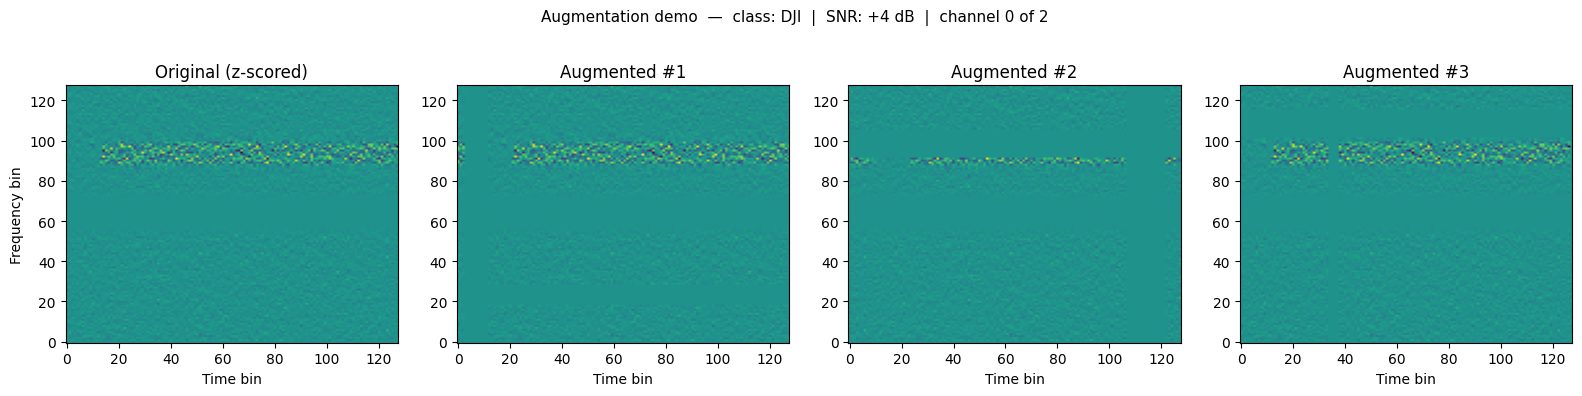

Saved: /content/drive/MyDrive/rf_drones/outputs3/figures3/augmentation_demo.png


In [70]:
import matplotlib.pyplot as plt

# Pick the first non-Noise drone sample from the train split.
drone_mask    = (y[train_idx] != NOISE_IDX).numpy()
first_drone_i = int(train_idx[drone_mask][0])

# Z-score it the same way IQDroneDataset would.
x_orig = x_spec[first_drone_i].float()
means  = x_orig.mean(dim=(1, 2), keepdim=True)
stds   = x_orig.std (dim=(1, 2), keepdim=True) + 1e-6
x_norm = (x_orig - means) / stds

# Three independent augmented copies (different RNG draws each call).
aug = SpectrogramAugmentations()
torch.manual_seed(1); x_a1 = aug(x_norm.clone())
torch.manual_seed(2); x_a2 = aug(x_norm.clone())
torch.manual_seed(3); x_a3 = aug(x_norm.clone())

panels = [("Original (z-scored)", x_norm),
          ("Augmented #1",        x_a1),
          ("Augmented #2",        x_a2),
          ("Augmented #3",        x_a3)]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
vmin = min(p[1][0].min().item() for p in panels)
vmax = max(p[1][0].max().item() for p in panels)
for ax, (title, img) in zip(axes, panels):
    ax.imshow(img[0].numpy(), aspect="auto", origin="lower", cmap="viridis", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("Time bin")
    ax.set_ylabel("Frequency bin" if ax is axes[0] else "")

fig.suptitle(
    f"Augmentation demo  —  class: {CLASS_NAMES[int(y[first_drone_i])]}  "
    f"|  SNR: {int(snr[first_drone_i]):+d} dB  "
    f"|  channel 0 of 2",
    fontsize=11,
)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(FIG_DIR / "augmentation_demo.png", dpi=120)
plt.show()

print(f"Saved: {FIG_DIR / 'augmentation_demo.png'}")

# 6. ResNet-18 Model implementation

In [71]:
import torch.nn as nn
import torchvision.models as tv_models

class DroneClassifier(nn.Module):
    """ResNet-18 backbone adapted to 2-channel spectrogram input + 7-way head.

    Exposes three forward modes:
      - forward(x)              -> logits   shape (B, NUM_CLASSES)
      - features(x)             -> embedding shape (B, 512)
      - forward_with_features(x) -> (logits, embedding) in a single backbone pass
    """

    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        backbone = tv_models.resnet18(weights=None)

        # Edit 1: swap conv1 from 3-channel (RGB) to 2-channel (I/Q spectrogram).
        backbone.conv1 = nn.Conv2d(
            in_channels=2,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False,
        )

        # Edit 2: peel off the 1,000-class fc; we add our own 7-class head.
        self.feature_dim = backbone.fc.in_features  # 512 for resnet18
        backbone.fc = nn.Identity()

        self.backbone = backbone
        self.head = nn.Linear(self.feature_dim, num_classes)

    def features(self, x):
        return self.backbone(x)

    def forward(self, x):
        return self.head(self.backbone(x))

    def forward_with_features(self, x):
        feats = self.backbone(x)
        return self.head(feats), feats

model = DroneClassifier(num_classes=NUM_CLASSES).to(DEVICE)

n_params     = sum(p.numel() for p in model.parameters())
n_trainable  = sum(p.numel() for p in model.parameters() if p.requires_grad)
size_mb      = n_params * 4 / 1e6   # float32 → 4 bytes/param

print(f"Model       : {type(model).__name__}")
print(f"  Backbone  : ResNet-18, conv1 in_channels=2, fc → Identity")
print(f"  Head      : Linear({model.feature_dim} → {NUM_CLASSES})")
print(f"  Params    : {n_params:,} total ({n_trainable:,} trainable)")
print(f"  Size      : ~{size_mb:.1f} MB on disk (float32)")
print(f"  Device    : {next(model.parameters()).device}")

Model       : DroneClassifier
  Backbone  : ResNet-18, conv1 in_channels=2, fc → Identity
  Head      : Linear(512 → 7)
  Params    : 11,176,967 total (11,176,967 trainable)
  Size      : ~44.7 MB on disk (float32)
  Device    : cuda:0


In [72]:
#
# logits shape (batch, 7)
# features shape (batch, 512)
#
#
#
import torch

xb, yb, sb = next(iter(train_loader))
xb = xb.to(DEVICE, non_blocking=True)

model.eval()
with torch.no_grad():
    logits  = model(xb)
    feats   = model.features(xb)
    logits2, feats2 = model.forward_with_features(xb)

assert logits.shape == (xb.size(0), NUM_CLASSES), f"unexpected logits shape: {logits.shape}"
assert feats.shape  == (xb.size(0), model.feature_dim), f"unexpected feats shape: {feats.shape}"
assert torch.allclose(logits, logits2, atol=1e-5), "logits differ between forward() and forward_with_features()"
assert torch.allclose(feats,  feats2,  atol=1e-5), "feats differ between features() and forward_with_features()"

print(f"Forward pass OK on batch of {xb.size(0)} samples")
print(f"  input  : {tuple(xb.shape)}")
print(f"  logits : {tuple(logits.shape)}  range [{logits.min().item():+.3f}, {logits.max().item():+.3f}]")
print(f"  feats  : {tuple(feats.shape)}    mean {feats.mean().item():+.4f}  std {feats.std().item():.4f}")

model.train()  # restore for any later training cells

Forward pass OK on batch of 128 samples
  input  : (128, 2, 128, 128)
  logits : (128, 7)  range [-2.929, +8.839]
  feats  : (128, 512)    mean +2.8722  std 2.4751


DroneClassifier(
  (backbone): ResNet(
    (conv1): Conv2d(2, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, 

# 7. Training



*   7.1 Class-weighted cross-entropy (loss)
*   7.2 Optimizer with LR Scheduler and AMP scaler
*   7.3 Evaluation helper
*   7.4 Training loop



## 7.1 Class-weighted loss

In [73]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter

# Inverse-frequency class weights from the train split only.
train_class_counts = Counter(y[train_idx].tolist())
total = sum(train_class_counts.values())

weights = torch.zeros(NUM_CLASSES)
for c in range(NUM_CLASSES):
    n = train_class_counts.get(c, 1)
    weights[c] = total / (NUM_CLASSES * n)

# Normalise so the mean weight = 1 (keeps loss magnitude comparable to plain CE).
weights = weights / weights.mean()
weights = weights.to(DEVICE)

print("Class weights for focal loss (train split):")
print(f"  {'class':<12}{'count':>8}{'weight':>10}")
print("  " + "-" * 30)
for c in range(NUM_CLASSES):
    print(f"  {CLASS_NAMES[c]:<12}{train_class_counts.get(c, 0):>8,}{weights[c].item():>10.4f}")

# ─── Class-weighted Focal Loss (Lin et al., ICCV 2017) ──────────────────────
# Robust composition with class weights:
#   1) Unweighted per-sample CE via F.cross_entropy(reduction="none").
#      = -log(p_t).  p_t = exp(-ce) = probability of the true class.
#   2) Focal modulation factor (1 - p_t)^gamma, DETACHED so it acts as a
#      static per-sample multiplier on the CE (this is the standard production
#      pattern; gradients flow through ce, not through the modulation).
#   3) Per-sample class weight applied LAST.
#
# Naive composition "F.cross_entropy(..., weight=w)" then "pt = exp(-ce)" is
# wrong — it produces pt = p^w, which crushes the loss for down-weighted
# classes regardless of model confidence.
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma  = gamma

    def forward(self, logits, target):
        ce = F.cross_entropy(logits, target, reduction="none")           # (B,) unweighted
        with torch.no_grad():
            pt           = torch.exp(-ce)                                # (B,) p_t (unweighted, static)
            focal_factor = (1 - pt) ** self.gamma                        # (B,) static modulation
        if self.weight is not None:
            w = self.weight[target]                                       # (B,)
        else:
            w = torch.ones_like(ce)
        return (w * focal_factor * ce).mean()

criterion = FocalLoss(weight=weights, gamma=2.0)
print(f"\ncriterion: {type(criterion).__name__}(gamma={criterion.gamma})")

Class weights for focal loss (train split):
  class          count    weight
  ------------------------------
  DJI            1,540    2.6460
  FutabaT14      4,856    0.8391
  FutabaT7       2,562    1.5905
  Graupner       4,536    0.8983
  Noise         36,786    0.1108
  Taranis       11,581    0.3519
  Turnigy        7,232    0.5634

criterion: FocalLoss(gamma=2.0)


## 7.2 Optimizer with LR Scheduler and AMP Scaler

In [74]:
import torch
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

# Linear warm-up (lr starts at 0.1 * LEARNING_RATE, climbs to LEARNING_RATE over WARMUP_EPOCHS)
warmup = LinearLR(
    optimizer,
    start_factor=0.1,
    end_factor=1.0,
    total_iters=WARMUP_EPOCHS,
)
# Cosine annealing for the remaining epochs (decays to 1% of peak)
cosine = CosineAnnealingLR(
    optimizer,
    T_max=max(1, EPOCHS - WARMUP_EPOCHS),
    eta_min=LEARNING_RATE * 0.01,
)
scheduler = SequentialLR(
    optimizer,
    schedulers=[warmup, cosine],
    milestones=[WARMUP_EPOCHS],
)

scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

print(f"Optimizer : AdamW(lr={LEARNING_RATE}, weight_decay={WEIGHT_DECAY})")
print(f"Scheduler : LinearLR warm-up {WARMUP_EPOCHS} epochs → CosineAnnealingLR over {EPOCHS - WARMUP_EPOCHS} epochs (eta_min={LEARNING_RATE * 0.01:.6g})")
print(f"AMP       : enabled={USE_AMP}")

Optimizer : AdamW(lr=0.001, weight_decay=0.0001)
Scheduler : LinearLR warm-up 3 epochs → CosineAnnealingLR over 27 epochs (eta_min=1e-05)
AMP       : enabled=True


## 7.3 Evaluation helper - evaluate()

In [75]:
import torch
import numpy as np
from sklearn.metrics import f1_score

@torch.no_grad()
def evaluate(model, loader, criterion=None):
    """Run model in eval mode over a loader. Returns (loss, acc, macro_f1, details_dict).

    If criterion is None, loss is set to NaN.
    """
    model.eval()
    loss_sum   = 0.0
    n_seen     = 0
    all_preds  = []
    all_labels = []
    all_snrs   = []
    all_logits = []

    for xb, yb, sb in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        yb_d = yb.to(DEVICE, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits = model(xb)
            if criterion is not None:
                loss = criterion(logits, yb_d)
                loss_sum += loss.item() * xb.size(0)

        all_preds.append(logits.argmax(1).cpu())
        all_labels.append(yb)
        all_snrs.append(sb)
        all_logits.append(logits.float().cpu())
        n_seen += xb.size(0)

    preds  = torch.cat(all_preds).numpy()
    labels = torch.cat(all_labels).numpy()
    snrs_  = torch.cat(all_snrs).numpy()
    logits_arr = torch.cat(all_logits).numpy()

    avg_loss = (loss_sum / n_seen) if criterion is not None else float("nan")
    accuracy = (preds == labels).mean()
    macro_f1 = f1_score(labels, preds, average="macro")

    details = {"preds": preds, "labels": labels, "snrs": snrs_, "logits": logits_arr}
    return avg_loss, accuracy, macro_f1, details

## 7.4 Training loop

1. train one epoch with AMP autocast and GradScaler
2. Evaluate on validation with evaluate()
3. Enable the LR scheduler
4. Append a row to the training_log.csv and print the one-line status
5. Save last.pt if the macro-F1 imrpoved, save best.pt and reset patience (else increment patience and early stop if patience >= early stop)

In [76]:


import csv
import time
import torch

log_path = OUT_DIR / "training_log.csv"
log_fields = [
    "epoch", "lr", "train_loss", "train_acc",
    "val_loss", "val_acc", "val_macro_f1", "epoch_time_s",
]

best_macro_f1    = -1.0
best_epoch       = -1
patience_counter = 0

log_file   = open(log_path, "w", newline="")
log_writer = csv.DictWriter(log_file, fieldnames=log_fields)
log_writer.writeheader()

try:
    for epoch in range(1, EPOCHS + 1):
        epoch_start = time.time()

        # ── Train one epoch ──────────────────────────────────────
        model.train()
        train_loss_sum = 0.0
        train_correct  = 0
        train_total    = 0

        for xb, yb, _ in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.amp.autocast("cuda", enabled=USE_AMP):
                logits = model(xb)
                loss   = criterion(logits, yb)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss_sum += loss.item() * xb.size(0)
            train_correct  += (logits.argmax(1) == yb).sum().item()
            train_total    += xb.size(0)

        train_loss = train_loss_sum / train_total
        train_acc  = train_correct  / train_total

        # ── Validate ─────────────────────────────────────────────
        val_loss, val_acc, val_macro_f1, _ = evaluate(model, val_loader, criterion)

        # ── LR scheduler step (per epoch) ────────────────────────
        scheduler.step()

        # ── Bookkeeping & logging ────────────────────────────────
        epoch_time = time.time() - epoch_start
        current_lr = optimizer.param_groups[0]["lr"]

        log_writer.writerow({
            "epoch":        epoch,
            "lr":           round(current_lr, 8),
            "train_loss":   round(train_loss, 4),
            "train_acc":    round(train_acc, 4),
            "val_loss":     round(val_loss, 4),
            "val_acc":      round(val_acc, 4),
            "val_macro_f1": round(val_macro_f1, 4),
            "epoch_time_s": round(epoch_time, 1),
        })
        log_file.flush()

        is_best = val_macro_f1 > best_macro_f1
        star    = "  ★ best" if is_best else ""
        print(
            f"Epoch {epoch:>2}/{EPOCHS}  lr={current_lr:.5f}  "
            f"train: loss={train_loss:.4f} acc={train_acc:.4f}  |  "
            f"val: loss={val_loss:.4f} acc={val_acc:.4f} f1={val_macro_f1:.4f}  "
            f"({epoch_time:.0f}s){star}"
        )

        # ── Checkpointing ────────────────────────────────────────
        torch.save(model.state_dict(), CKPT_DIR / "last.pt")
        if is_best:
            best_macro_f1    = val_macro_f1
            best_epoch       = epoch
            patience_counter = 0
            torch.save(model.state_dict(), CKPT_DIR / "best.pt")
        else:
            patience_counter += 1
            if patience_counter >= EARLY_STOP_PATIENCE:
                print(f"\nEarly stopping at epoch {epoch} "
                      f"(no val_macro_f1 improvement for {EARLY_STOP_PATIENCE} epochs).")
                break

except KeyboardInterrupt:
    print("\nInterrupted by user — saving current state and continuing.")

finally:
    log_file.close()

# Reload best weights so the model in memory is the one Section 8/9/10 should use.
best_path = CKPT_DIR / "best.pt"
if best_path.exists() and best_epoch > 0:
    model.load_state_dict(torch.load(best_path, map_location=DEVICE))
    print(f"\nLoaded best.pt (epoch {best_epoch}, val_macro_f1={best_macro_f1:.4f})")

print(f"Training log: {log_path}")
print(f"Checkpoints : {CKPT_DIR}")

Epoch  1/30  lr=0.00040  train: loss=0.3238 acc=0.7114  |  val: loss=0.2107 acc=0.8280 f1=0.7242  (37s)  ★ best
Epoch  2/30  lr=0.00070  train: loss=0.2380 acc=0.7529  |  val: loss=0.1854 acc=0.8465 f1=0.7386  (37s)  ★ best
Epoch  3/30  lr=0.00100  train: loss=0.2007 acc=0.7924  |  val: loss=0.1548 acc=0.8577 f1=0.7644  (37s)  ★ best
Epoch  4/30  lr=0.00100  train: loss=0.1755 acc=0.8199  |  val: loss=0.1432 acc=0.8892 f1=0.8195  (38s)  ★ best
Epoch  5/30  lr=0.00099  train: loss=0.1549 acc=0.8453  |  val: loss=0.1162 acc=0.8685 f1=0.8106  (37s)
Epoch  6/30  lr=0.00097  train: loss=0.1458 acc=0.8519  |  val: loss=0.1192 acc=0.8645 f1=0.7975  (37s)
Epoch  7/30  lr=0.00095  train: loss=0.1351 acc=0.8627  |  val: loss=0.1317 acc=0.8551 f1=0.7878  (37s)
Epoch  8/30  lr=0.00092  train: loss=0.1295 acc=0.8661  |  val: loss=0.1119 acc=0.8361 f1=0.7916  (37s)
Epoch  9/30  lr=0.00088  train: loss=0.1222 acc=0.8693  |  val: loss=0.1104 acc=0.8892 f1=0.8231  (37s)  ★ best
Epoch 10/30  lr=0.00084 

# 8. Evaluation of the test slit

## Headline Metrics and per class table

In [77]:
import torch
from sklearn.metrics import precision_recall_fscore_support

model.eval()
test_loss, test_acc, test_macro_f1, test_details = evaluate(model, test_loader, criterion)

preds  = test_details["preds"]
labels = test_details["labels"]
snrs_t = test_details["snrs"]

print("Test set — headline metrics")
print(f"  Samples  : {len(labels):,}")
print(f"  Loss     : {test_loss:.4f}")
print(f"  Accuracy : {test_acc:.4f}  ({test_acc * 100:.2f}%)")
print(f"  Macro-F1 : {test_macro_f1:.4f}")
print()

prec, rec, f1, supp = precision_recall_fscore_support(
    labels, preds, labels=list(range(NUM_CLASSES)), zero_division=0
)

print(f"{'Class':<12}{'Precision':>12}{'Recall':>10}{'F1':>10}{'Support':>12}")
print("-" * 56)
for i in range(NUM_CLASSES):
    print(f"{CLASS_NAMES[i]:<12}{prec[i]:>12.4f}{rec[i]:>10.4f}{f1[i]:>10.4f}{int(supp[i]):>12,}")
print("-" * 56)
print(f"{'Macro avg':<12}{prec.mean():>12.4f}{rec.mean():>10.4f}{f1.mean():>10.4f}{int(supp.sum()):>12,}")

Test set — headline metrics
  Samples  : 14,806
  Loss     : 0.0946
  Accuracy : 0.9219  (92.19%)
  Macro-F1 : 0.8772

Class          Precision    Recall        F1     Support
--------------------------------------------------------
DJI               0.7586    0.8123    0.7845         325
FutabaT14         0.8845    0.8471    0.8654       1,040
FutabaT7          0.7765    0.8318    0.8032         547
Graupner          0.9103    0.9178    0.9140         973
Noise             0.9344    0.9486    0.9415       7,887
Taranis           0.9797    0.9544    0.9669       2,480
Turnigy           0.8886    0.8417    0.8645       1,554
--------------------------------------------------------
Macro avg         0.8761    0.8791    0.8772      14,806


## Confusion matrix

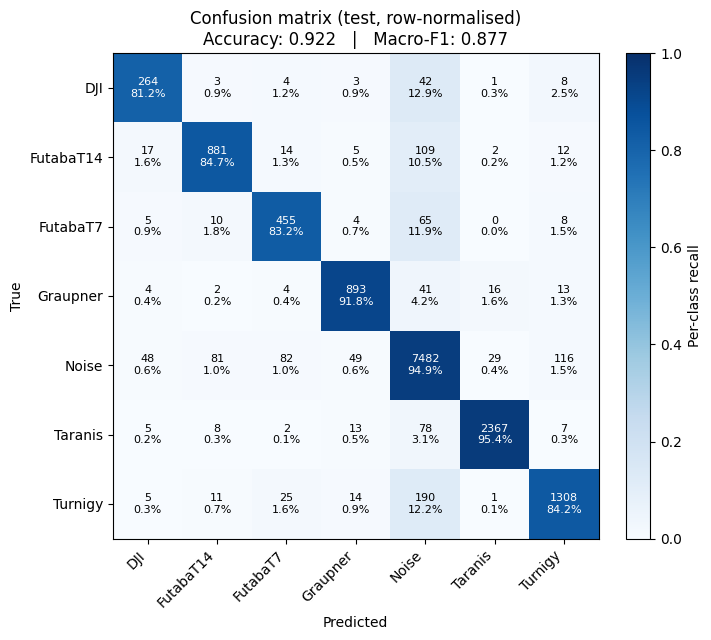

Saved: /content/drive/MyDrive/rf_drones/outputs3/figures3/confusion_matrix.png


In [78]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm      = confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))
row_sum = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sum, where=row_sum != 0)

names = [CLASS_NAMES[i] for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)

ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_yticklabels(names)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        n   = int(cm[i, j])
        pct = cm_norm[i, j]
        text_color = "white" if pct > 0.5 else "black"
        ax.text(j, i, f"{n}\n{pct:.1%}", ha="center", va="center",
                fontsize=8, color=text_color)

ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(
    f"Confusion matrix (test, row-normalised)\n"
    f"Accuracy: {test_acc:.3f}   |   Macro-F1: {test_macro_f1:.3f}"
)
fig.colorbar(im, ax=ax, label="Per-class recall", fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(FIG_DIR / "confusion_matrix.png", dpi=120)
plt.show()
print(f"Saved: {FIG_DIR / 'confusion_matrix.png'}")

## Per SNR accuracy curve

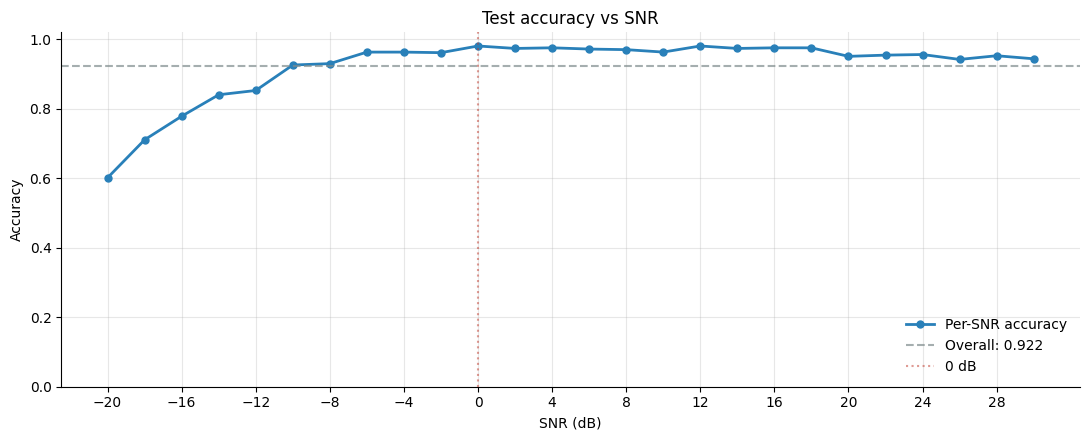


  SNR (dB)   samples    accuracy
       -20       567      0.6014
       -18       567      0.7108
       -16       569      0.7786
       -14       570      0.8404
       -12       570      0.8526
       -10       567      0.9259
        -8       571      0.9299
        -6       569      0.9631
        -4       569      0.9631
        -2       571      0.9615
        +0       570      0.9807
        +2       569      0.9736
        +4       571      0.9755
        +6       569      0.9719
        +8       570      0.9702
       +10       570      0.9632
       +12       570      0.9807
       +14       569      0.9736
       +16       570      0.9754
       +18       569      0.9754
       +20       570      0.9509
       +22       570      0.9544
       +24       570      0.9561
       +26       569      0.9420
       +28       570      0.9526
       +30       570      0.9439

Saved: /content/drive/MyDrive/rf_drones/outputs3/figures3/per_snr_accuracy.png


In [79]:
import matplotlib.pyplot as plt
import numpy as np

unique_snrs = sorted(set(int(s) for s in snrs_t.tolist()))
per_snr_acc = []
per_snr_n   = []
for s in unique_snrs:
    mask = snrs_t == s
    n    = int(mask.sum())
    acc  = float((preds[mask] == labels[mask]).mean()) if n > 0 else float("nan")
    per_snr_acc.append(acc)
    per_snr_n.append(n)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(unique_snrs, per_snr_acc, marker="o", color="#2980b9",
        linewidth=2, markersize=5, label="Per-SNR accuracy")
ax.axhline(test_acc, color="#7f8c8d", linestyle="--", alpha=0.7,
           label=f"Overall: {test_acc:.3f}")
ax.axvline(0, color="#c0392b", linestyle=":", alpha=0.5, label="0 dB")
ax.set_xlabel("SNR (dB)")
ax.set_ylabel("Accuracy")
ax.set_title("Test accuracy vs SNR")
ax.set_ylim(0, 1.02)
ax.set_xticks(unique_snrs[::2])
ax.grid(alpha=0.3)
ax.legend(loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "per_snr_accuracy.png", dpi=120)
plt.show()

print()
print(f"{'SNR (dB)':>10}{'samples':>10}{'accuracy':>12}")
for s, n, acc in zip(unique_snrs, per_snr_n, per_snr_acc):
    print(f"{s:>+10d}{n:>10,}{acc:>12.4f}")
print(f"\nSaved: {FIG_DIR / 'per_snr_accuracy.png'}")

# 9. Friend gate (OOD calibration)

## 9.1 Get training embeddings (without augmentation)

In [80]:
import torch

@torch.no_grad()
def collect_features(model, loader):
    """Return (feats, labels, logits) tensors collected over the full loader."""
    model.eval()
    feats_chunks, label_chunks, logit_chunks = [], [], []
    for xb, yb, _ in loader:
        xb = xb.to(DEVICE, non_blocking=True)
        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits, feats = model.forward_with_features(xb)
        feats_chunks.append(feats.float().cpu())
        logit_chunks.append(logits.float().cpu())
        label_chunks.append(yb)
    return torch.cat(feats_chunks), torch.cat(label_chunks), torch.cat(logit_chunks)

# Disable train augmentation while we fit OOD statistics, then restore.
_saved_train_transform = train_ds.transform
train_ds.transform = None
try:
    print("Collecting train features (no augmentation)...")
    train_feats, train_labels, _ = collect_features(model, train_loader)
finally:
    train_ds.transform = _saved_train_transform

print("Collecting val features...")
val_feats, val_labels, val_logits = collect_features(model, val_loader)

print()
print(f"train_feats : {tuple(train_feats.shape)}  {train_feats.dtype}")
print(f"val_feats   : {tuple(val_feats.shape)}    {val_feats.dtype}")
print(f"val_logits  : {tuple(val_logits.shape)}    {val_logits.dtype}")


train_feats : (68992, 512)  torch.float32
val_feats   : (14806, 512)    torch.float32
val_logits  : (14806, 7)    torch.float32


## 9.2 Construct the in-distribution reference for OOD (using the KNN reference w/ drone embeddings, L2-normalised)

In [81]:
import torch
import torch.nn.functional as F

# Filter train features to friendly drones only (exclude Noise).
drone_mask_train  = (train_labels != NOISE_IDX)
train_drone_feats = train_feats[drone_mask_train]
train_drone_labels = train_labels[drone_mask_train]

# L2-normalise so KNN distance is scale-invariant (equivalent to cosine distance).
train_drone_feats_norm = F.normalize(train_drone_feats, dim=1, p=2)

ref_mb = train_drone_feats_norm.element_size() * train_drone_feats_norm.nelement() / 1e6
print(f"Drone reference set: {train_drone_feats_norm.shape[0]:,} samples × "
      f"{train_drone_feats_norm.shape[1]} features  ({ref_mb:.1f} MB)")
print()
print("Per-class drone reference counts:")
for c in FRIENDLY_IDX:
    n = int((train_drone_labels == c).sum().item())
    print(f"  {CLASS_NAMES[c]:<12}: {n:>6,}")

Drone reference set: 32,264 samples × 512 features  (66.1 MB)

Per-class drone reference counts:
  DJI         :  1,536
  FutabaT14   :  4,848
  FutabaT7    :  2,562
  Graupner    :  4,529
  Taranis     : 11,563
  Turnigy     :  7,226


## 9.3 Score validation and calibrate the thresholds including an AUROC sanity check

Cost-sensitive calibration  (C_FF = 10.0, C_MF = 1.0)
K = 10, drone reference size = 32,264

Score            tau    AUROC vs Noise    Min cost   False-foe @ tau
--------------------------------------------------------------------
Energy       -1.7209            0.8429      1.0000            0.00%  (vs 0% Noise above)
KNN           0.2153            0.8916      0.9986            0.00%  (vs 0% Noise above)


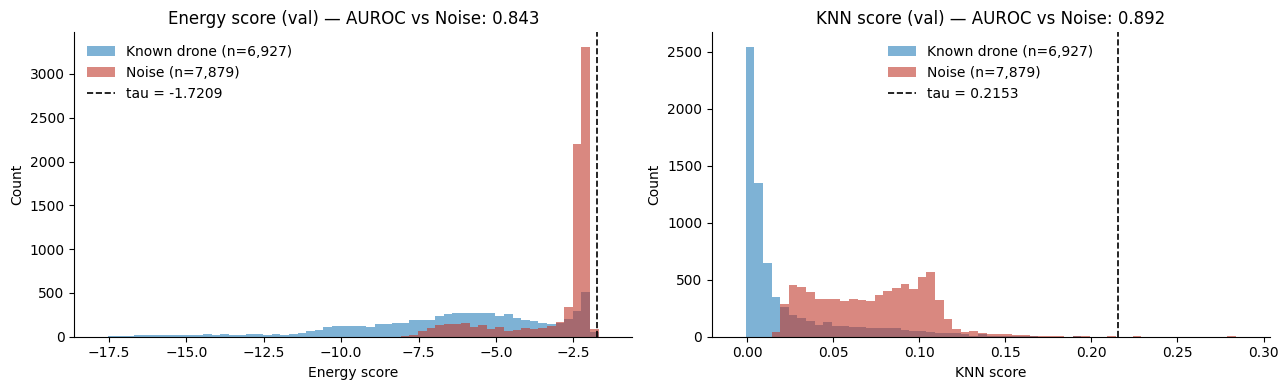

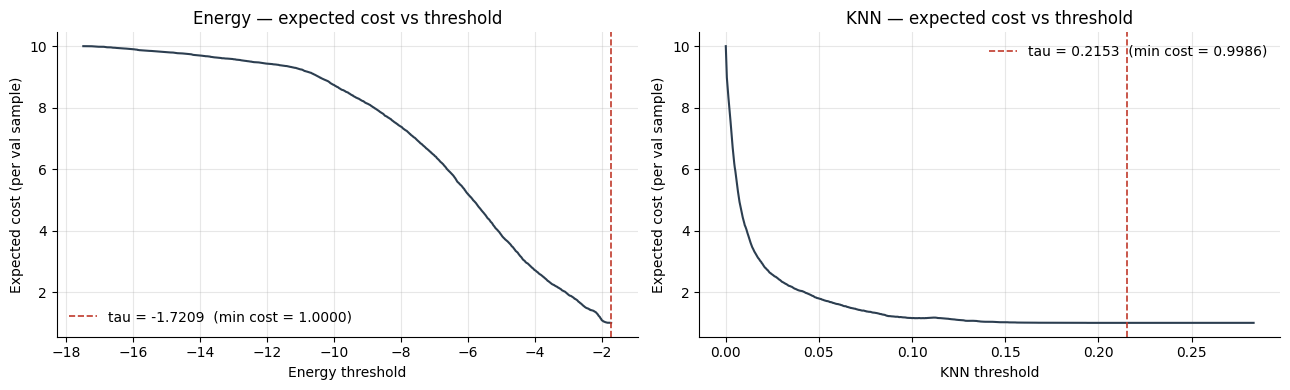

Saved: /content/drive/MyDrive/rf_drones/outputs3/figures3/ood_score_distributions.png
Saved: /content/drive/MyDrive/rf_drones/outputs3/figures3/ood_cost_curves.png


In [82]:
# Cost-sensitive threshold calibration (replaces 99th-percentile target).
# Friend/foe is asymmetric: engaging a friendly drone is much worse than
# letting an unknown emitter through. We pick τ that minimises *expected cost*
# rather than hitting a fixed false-foe rate.
#
# Reference: Elkan, "The foundations of cost-sensitive learning", IJCAI 2001.

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score

K_NEIGHBORS = 10

def knn_distance(query_feats_norm, ref_feats_norm, k=K_NEIGHBORS, chunk=512):
    """Distance to the k-th nearest neighbour for each query.
    Both inputs must be L2-normalised. Cosine distance = 1 - dot product.
    Chunked to keep memory bounded by O(chunk * N_ref).
    """
    out = []
    for i in range(0, len(query_feats_norm), chunk):
        q     = query_feats_norm[i:i + chunk]
        sims  = q @ ref_feats_norm.T
        dists = 1.0 - sims
        knn_d, _ = dists.topk(k, dim=1, largest=False)
        out.append(knn_d[:, -1])
    return torch.cat(out)

# Score val samples
val_feats_norm = F.normalize(val_feats, dim=1, p=2)
val_energy = -torch.logsumexp(val_logits, dim=1).numpy()
val_knn    = knn_distance(val_feats_norm, train_drone_feats_norm,
                          k=K_NEIGHBORS).numpy()

known_drone_mask = (val_labels.numpy() != NOISE_IDX)

# ─── Cost matrix ──────────────────────────────────────────────────────────
#   C_FF = 100  → false-foe: friendly drone flagged as foe (engaging own asset)
#   C_MF =   1  → missed-foe: unknown emitter flagged as friend (recoverable)
COST_FF = 10.0
COST_MF =   1.0

def cost_min_threshold(scores, known_mask, c_ff, c_mf, n_grid=1000):
    """Sweep τ over the score range, return the τ minimising expected cost on val."""
    grid = np.linspace(scores.min(), scores.max(), n_grid)
    costs = []
    for t in grid:
        p_false_foe  = (scores[known_mask]  >  t).mean()   # friendly flagged as foe
        p_missed_foe = (scores[~known_mask] <= t).mean()   # noise NOT flagged
        costs.append(c_ff * p_false_foe + c_mf * p_missed_foe)
    costs = np.array(costs)
    return float(grid[int(np.argmin(costs))]), grid, costs

tau_E,   grid_E,   costs_E   = cost_min_threshold(val_energy, known_drone_mask, COST_FF, COST_MF)
tau_KNN, grid_KNN, costs_KNN = cost_min_threshold(val_knn,    known_drone_mask, COST_FF, COST_MF)

# AUROC sanity check (Noise as proxy for "unknown")
ood_target = (~known_drone_mask).astype(int)
auroc_E    = roc_auc_score(ood_target, val_energy)
auroc_KNN  = roc_auc_score(ood_target, val_knn)

# Report
print(f"Cost-sensitive calibration  (C_FF = {COST_FF}, C_MF = {COST_MF})")
print(f"K = {K_NEIGHBORS}, drone reference size = {len(train_drone_feats_norm):,}")
print()
print(f"{'Score':<10}{'tau':>10}{'AUROC vs Noise':>18}{'Min cost':>12}{'False-foe @ tau':>18}")
print("-" * 68)
for name, scores, tau, auroc, cost_arr in [
    ("Energy", val_energy, tau_E,   auroc_E,   costs_E),
    ("KNN",    val_knn,    tau_KNN, auroc_KNN, costs_KNN),
]:
    drone_above = (scores[known_drone_mask] > tau).mean()
    noise_above = (scores[~known_drone_mask] > tau).mean()
    print(f"{name:<10}{tau:>10.4f}{auroc:>18.4f}{cost_arr.min():>12.4f}{drone_above:>17.2%}"
          f"  (vs {noise_above:.0%} Noise above)")

# ─── Score distribution plots (unchanged) ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (name, scores, tau, auroc) in zip(axes, [
    ("Energy", val_energy, tau_E,   auroc_E),
    ("KNN",    val_knn,    tau_KNN, auroc_KNN),
]):
    drone_scores = scores[known_drone_mask]
    noise_scores = scores[~known_drone_mask]
    spread = max(scores.max() - scores.min(), 1e-6)
    bins = np.linspace(scores.min() - 0.02 * spread,
                       scores.max() + 0.02 * spread, 60)
    ax.hist(drone_scores, bins=bins, alpha=0.6, color="#2980b9",
            label=f"Known drone (n={len(drone_scores):,})")
    ax.hist(noise_scores, bins=bins, alpha=0.6, color="#c0392b",
            label=f"Noise (n={len(noise_scores):,})")
    ax.axvline(tau, color="black", linestyle="--", linewidth=1.2,
               label=f"tau = {tau:.4f}")
    ax.set_title(f"{name} score (val) — AUROC vs Noise: {auroc:.3f}")
    ax.set_xlabel(f"{name} score")
    ax.set_ylabel("Count")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "ood_score_distributions.png", dpi=120)
plt.show()

# ─── New: expected-cost vs τ curves (auditable cost minimum) ──────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (name, grid, costs, tau) in zip(axes, [
    ("Energy", grid_E,   costs_E,   tau_E),
    ("KNN",    grid_KNN, costs_KNN, tau_KNN),
]):
    ax.plot(grid, costs, color="#2c3e50", linewidth=1.5)
    ax.axvline(tau, color="#c0392b", linestyle="--", linewidth=1.2,
               label=f"tau = {tau:.4f}  (min cost = {costs.min():.4f})")
    ax.set_xlabel(f"{name} threshold")
    ax.set_ylabel("Expected cost (per val sample)")
    ax.set_title(f"{name} — expected cost vs threshold")
    ax.legend(frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "ood_cost_curves.png", dpi=120)
plt.show()

print(f"Saved: {FIG_DIR / 'ood_score_distributions.png'}")
print(f"Saved: {FIG_DIR / 'ood_cost_curves.png'}")


## 9.4 Persist the OOD statistics under a .pt file

In [84]:
import torch

ood_stats_path = OUT_DIR / "ood_stats.pt"
ood_stats = {
    "train_drone_feats_norm": train_drone_feats_norm.cpu(),  # (N_drones, 512), L2-normed
    "tau_E":                  float(tau_E),
    "tau_KNN":                float(tau_KNN),
    "K":                      int(K_NEIGHBORS),
    "noise_idx":              int(NOISE_IDX),
    "friendly_idx":           list(FRIENDLY_IDX),
    "false_foe_target":       float(OOD_TARGET_FALSE_FOE_RATE),
    "feat_dim":               int(val_feats.shape[1]),
    "ood_method":             "energy + knn (Sun et al., ICML 2022)",
}
torch.save(ood_stats, ood_stats_path)
size_mb = ood_stats_path.stat().st_size / 1e6

print(f"Saved ood_stats.pt to {ood_stats_path}  ({size_mb:.1f} MB)")
print()
print("Contents:")
for k, v in ood_stats.items():
    if isinstance(v, torch.Tensor):
        print(f"  {k:<24}: tensor {tuple(v.shape)}  {v.dtype}")
    else:
        print(f"  {k:<24}: {v}")

Saved ood_stats.pt to /content/drive/MyDrive/rf_drones/outputs3/ood_stats.pt  (66.1 MB)

Contents:
  train_drone_feats_norm  : tensor (32264, 512)  torch.float32
  tau_E                   : -1.7208539247512817
  tau_KNN                 : 0.21526557207107544
  K                       : 10
  noise_idx               : 4
  friendly_idx            : [0, 1, 2, 3, 5, 6]
  false_foe_target        : 0.01
  feat_dim                : 512
  ood_method              : energy + knn (Sun et al., ICML 2022)


# 10. Inference

## 10.1 Build the DronePredictor class

Self-contained class that:

* owns the trained model
* owns the OOD reference embd + thresholds + K
* owns the class-name registry

In [85]:
import torch
import torch.nn.functional as F

class DronePredictor:
    """Deployable friend/foe predictor — model + OOD detector in one object."""

    def __init__(self, model, ood_stats, class_names, device):
        self.model        = model.eval()
        self.device       = device
        self.class_names  = class_names

        # Move OOD reference + scalars onto the inference device once at construction.
        self.train_drone_feats_norm = ood_stats["train_drone_feats_norm"].to(device)
        self.tau_E       = float(ood_stats["tau_E"])
        self.tau_KNN     = float(ood_stats["tau_KNN"])
        self.K           = int(ood_stats["K"])
        self.noise_idx   = int(ood_stats["noise_idx"])

    @staticmethod
    def _normalize(x):
        """Per-sample, per-channel z-score (matches IQDroneDataset)."""
        means = x.mean(dim=(-1, -2), keepdim=True)
        stds  = x.std (dim=(-1, -2), keepdim=True) + 1e-6
        return (x - means) / stds

    @torch.no_grad()
    def predict(self, x_spec):
        """Returns a list of dicts (one per sample), each with:
            verdict          : 'friend' or 'foe'
            label            : drone name, 'noise', or 'unknown'
            predicted_class  : argmax class name (regardless of verdict)
            argmax_idx       : argmax class index
            energy           : energy score (lower = more confident)
            knn              : k-th NN cosine distance (lower = closer to known drones)
            trigger          : which gate fired ('argmax_noise', 'energy', 'knn', 'energy+knn', 'ok')
        """
        if x_spec.ndim == 3:
            x_spec = x_spec.unsqueeze(0)

        x = self._normalize(x_spec.float()).to(self.device, non_blocking=True)
        logits, feats = self.model.forward_with_features(x)

        argmax = logits.argmax(dim=1)
        energy = -torch.logsumexp(logits, dim=1)

        feats_norm = F.normalize(feats, dim=1, p=2)
        sims  = feats_norm @ self.train_drone_feats_norm.T
        dists = 1.0 - sims
        knn_d, _ = dists.topk(self.K, dim=1, largest=False)
        knn  = knn_d[:, -1]

        # Move everything to CPU once for Python-level decisioning.
        argmax_n = argmax.cpu().numpy()
        energy_n = energy.cpu().numpy()
        knn_n    = knn.cpu().numpy()

        results = []
        for i in range(len(argmax_n)):
            cls = int(argmax_n[i])
            e   = float(energy_n[i])
            k   = float(knn_n[i])

            if cls == self.noise_idx:
                verdict, label, trigger = "foe", "noise", "argmax_noise"
            else:
                e_high = e > self.tau_E
                k_high = k > self.tau_KNN
                if e_high or k_high:
                    fired = []
                    if e_high: fired.append("energy")
                    if k_high: fired.append("knn")
                    verdict, label, trigger = "foe", "unknown", "+".join(fired)
                else:
                    verdict, label, trigger = "friend", self.class_names[cls], "ok"

            results.append({
                "verdict":         verdict,
                "label":           label,
                "predicted_class": self.class_names[cls],
                "argmax_idx":      cls,
                "energy":          e,
                "knn":             k,
                "trigger":         trigger,
            })

        return results

# Instantiate using the in-memory model and the ood_stats.pt we just saved.
_loaded_ood_stats = torch.load(OUT_DIR / "ood_stats.pt", map_location=DEVICE, weights_only=False)
predictor = DronePredictor(
    model=model,
    ood_stats=_loaded_ood_stats,
    class_names=CLASS_NAMES,
    device=DEVICE,
)

print("DronePredictor ready.")
print(f"  tau_E       : {predictor.tau_E:+.4f}")
print(f"  tau_KNN     : {predictor.tau_KNN:.4f}")
print(f"  K           : {predictor.K}")
print(f"  Reference   : {tuple(predictor.train_drone_feats_norm.shape)}")
print(f"  Device      : {predictor.device}")

DronePredictor ready.
  tau_E       : -1.7209
  tau_KNN     : 0.2153
  K           : 10
  Reference   : (32264, 512)
  Device      : cuda


## 10.2 Demo with real test samples (including a synthetic random noise tensor)

In [86]:
import torch
import numpy as np

# One real sample per known class (drones + Noise) from the test split.
demo_indices = []
for c in range(NUM_CLASSES):
    matches = test_idx[(y[test_idx] == c).numpy()]
    if len(matches) > 0:
        demo_indices.append((int(matches[0]), c))

header = (
    f"{'idx':>6}  {'true':<10}  {'snr':>5}  {'verdict':<7}  "
    f"{'label':<12}  {'argmax':<10}  {'energy':>8}  {'knn':>8}  trigger"
)
print(header)
print("-" * len(header))

for idx, true_c in demo_indices:
    x_sample = x_spec[idx]                       # (2, 128, 128) raw, before z-score
    true_name = CLASS_NAMES[true_c]
    snr_val   = int(snr[idx])
    r = predictor.predict(x_sample)[0]
    print(f"{idx:>6}  {true_name:<10}  {snr_val:>+5d}  {r['verdict']:<7}  "
          f"{r['label']:<12}  {r['predicted_class']:<10}  {r['energy']:>+8.2f}  "
          f"{r['knn']:>8.4f}  {r['trigger']}")

# Synthetic random-noise tensor (definitely OOD)
print()
print("Synthetic Gaussian noise tensor (definitely not in training distribution):")
torch.manual_seed(0)
synthetic = torch.randn(2, 128, 128)
r = predictor.predict(synthetic)[0]
print(f"  verdict={r['verdict']}  label={r['label']}  "
      f"argmax={r['predicted_class']}  energy={r['energy']:+.2f}  "
      f"knn={r['knn']:.4f}  trigger={r['trigger']}")

# A tougher unknown: random IQ-shaped tensor with similar statistics to real data
print()
print("Synthetic 'plausible' random tensor (matched to real spectrogram stats):")
synthetic_plausible = torch.randn(2, 128, 128) * 1.5   # slightly higher variance
r = predictor.predict(synthetic_plausible)[0]
print(f"  verdict={r['verdict']}  label={r['label']}  "
      f"argmax={r['predicted_class']}  energy={r['energy']:+.2f}  "
      f"knn={r['knn']:.4f}  trigger={r['trigger']}")

   idx  true          snr  verdict  label         argmax        energy       knn  trigger
-----------------------------------------------------------------------------------------
     1  DJI            +8  friend   DJI           DJI            -3.79    0.0066  ok
  2216  FutabaT14     -10  friend   FutabaT14     FutabaT14      -2.51    0.0552  ok
  9147  FutabaT7      +22  friend   FutabaT7      FutabaT7       -3.32    0.0564  ok
 12793  Graupner      +20  friend   Graupner      Graupner       -9.68    0.0014  ok
 46157  Noise         -18  foe      noise         Noise          -2.29    0.0804  argmax_noise
 19285  Taranis        +4  friend   Taranis       Taranis        -6.70    0.0029  ok
 35824  Turnigy       +12  friend   Turnigy       Turnigy        -3.44    0.0479  ok

Synthetic Gaussian noise tensor (definitely not in training distribution):
  verdict=foe  label=noise  argmax=Noise  energy=-1.92  knn=0.1041  trigger=argmax_noise

Synthetic 'plausible' random tensor (matched to r

# 11. export for deployment

* TorchScript (model.pt): native serialisation.
* ONNX (model.onnx): cross-framework format (runs for NVIDIA Jetson, ONNXRuntime, and other).
* Parity check: verifies that PyTorch/TorchScript/ONNX produce idential predictions on a 100-sample probe.

## 11.1 TorchScript export

In [87]:
import torch

class _ExportWrapper(torch.nn.Module):
    """Wraps DroneClassifier so a single forward returns (logits, features)."""
    def __init__(self, base):
        super().__init__()
        self.base = base
    def forward(self, x):
        return self.base.forward_with_features(x)

export_model = _ExportWrapper(model).eval().to(DEVICE)

# Dummy input for tracing; batch size 1 is the smallest deployable unit.
dummy_input = torch.randn(1, 2, 128, 128, device=DEVICE)

with torch.no_grad():
    traced = torch.jit.trace(export_model, dummy_input, strict=False)

torchscript_path = OUT_DIR / "model.pt"
traced.save(torchscript_path)

size_mb = torchscript_path.stat().st_size / 1e6
print(f"Saved TorchScript to {torchscript_path}  ({size_mb:.1f} MB)")

# Quick smoke load + forward to confirm the file is valid.
_loaded = torch.jit.load(torchscript_path).to(DEVICE).eval()
with torch.no_grad():
    _logits, _feats = _loaded(dummy_input)
print(f"  Smoke forward: logits {tuple(_logits.shape)}, feats {tuple(_feats.shape)}")

Saved TorchScript to /content/drive/MyDrive/rf_drones/outputs3/model.pt  (44.9 MB)
  Smoke forward: logits (1, 7), feats (1, 512)


## 11.2 ONNX report

In [88]:
import numpy as np
import onnxruntime as ort
import torch

onnx_path = OUT_DIR / "model.onnx"

with torch.no_grad():
    torch.onnx.export(
        export_model,
        dummy_input,
        onnx_path,
        input_names=["spectrogram"],
        output_names=["logits", "features"],
        dynamic_axes={
            "spectrogram": {0: "batch"},
            "logits":      {0: "batch"},
            "features":    {0: "batch"},
        },
        opset_version=17,
        do_constant_folding=True,
        dynamo=False,   # use legacy TorchScript-based exporter (single-file, weights inline)
    )

size_mb = onnx_path.stat().st_size / 1e6
print(f"Saved ONNX to {onnx_path}  ({size_mb:.1f} MB)")

# Smoke load with onnxruntime.
providers = ["CUDAExecutionProvider", "CPUExecutionProvider"]
ort_session = ort.InferenceSession(str(onnx_path), providers=providers)
ort_outputs = ort_session.run(None, {"spectrogram": dummy_input.cpu().numpy()})
_onnx_logits, _onnx_feats = ort_outputs
print(f"  Smoke forward: logits {_onnx_logits.shape}, feats {_onnx_feats.shape}")
print(f"  Active provider: {ort_session.get_providers()[0]}")

/tmp/ipykernel_763/3893610981.py:8: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Saved ONNX to /content/drive/MyDrive/rf_drones/outputs3/model.onnx  (44.7 MB)
  Smoke forward: logits (1, 7), feats (1, 512)
  Active provider: CPUExecutionProvider


/usr/local/lib/python3.12/dist-packages/onnxruntime/capi/onnxruntime_inference_collection.py:148: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


## 11.3 Parity check (100-sample probe)

In [89]:
import numpy as np
import torch
import onnxruntime as ort

# Build the 100-sample probe — first 100 indices from the test split.
probe_indices = test_idx[:100]
probe_x_raw = torch.stack([x_spec[int(i)].float() for i in probe_indices])

# Apply the same z-score the predictor would apply.
_means = probe_x_raw.mean(dim=(-1, -2), keepdim=True)
_stds  = probe_x_raw.std (dim=(-1, -2), keepdim=True) + 1e-6
probe_x = (probe_x_raw - _means) / _stds
probe_x = probe_x.to(DEVICE)

# 1) Live PyTorch
model.eval()
with torch.no_grad():
    py_logits, py_feats = model.forward_with_features(probe_x)
py_logits_np = py_logits.cpu().numpy()
py_feats_np  = py_feats.cpu().numpy()

# 2) TorchScript
ts_loaded = torch.jit.load(torchscript_path).to(DEVICE).eval()
with torch.no_grad():
    ts_logits, ts_feats = ts_loaded(probe_x)
ts_logits_np = ts_logits.cpu().numpy()
ts_feats_np  = ts_feats.cpu().numpy()

# 3) ONNX
ort_outputs = ort_session.run(None, {"spectrogram": probe_x.cpu().numpy()})
onnx_logits_np, onnx_feats_np = ort_outputs

def max_abs_diff(a, b):
    return float(np.abs(a - b).max())

py_argmax   = py_logits_np.argmax(axis=1)
ts_argmax   = ts_logits_np.argmax(axis=1)
onnx_argmax = onnx_logits_np.argmax(axis=1)

print("Parity check (100-sample probe)\n")
print(f"{'comparison':<32}{'logits max|diff|':>20}{'feats max|diff|':>20}{'argmax agreement':>22}")
print("-" * 94)
rows = [
    ("PyTorch  vs  TorchScript", py_logits_np, ts_logits_np, py_feats_np, ts_feats_np, py_argmax, ts_argmax),
    ("PyTorch  vs  ONNX",        py_logits_np, onnx_logits_np, py_feats_np, onnx_feats_np, py_argmax, onnx_argmax),
    ("TorchScript  vs  ONNX",    ts_logits_np, onnx_logits_np, ts_feats_np, onnx_feats_np, ts_argmax, onnx_argmax),
]
for label, la, lb, fa, fb, aa, ab in rows:
    print(f"{label:<32}{max_abs_diff(la, lb):>20.2e}{max_abs_diff(fa, fb):>20.2e}"
          f"{(aa == ab).mean():>21.2%}")

# Final summary
all_argmax_ok = (py_argmax == ts_argmax).all() and (py_argmax == onnx_argmax).all()
print()
print("OK: all three formats agree on every argmax" if all_argmax_ok
      else "WARNING: argmax disagreements detected — investigate before deploying")
print(f"\nDeployable artefacts on Drive:")
print(f"  {torchscript_path}")
print(f"  {onnx_path}")
print(f"  {OUT_DIR / 'ood_stats.pt'}")

Parity check (100-sample probe)

comparison                          logits max|diff|     feats max|diff|      argmax agreement
----------------------------------------------------------------------------------------------
PyTorch  vs  TorchScript                    0.00e+00            0.00e+00              100.00%
PyTorch  vs  ONNX                           1.37e-03            8.42e-04              100.00%
TorchScript  vs  ONNX                       1.37e-03            8.42e-04              100.00%

OK: all three formats agree on every argmax

Deployable artefacts on Drive:
  /content/drive/MyDrive/rf_drones/outputs3/model.pt
  /content/drive/MyDrive/rf_drones/outputs3/model.onnx
  /content/drive/MyDrive/rf_drones/outputs3/ood_stats.pt


# 12. Knowledege distillation (optional)

## 12.1 Define the StudentClassifier

In [90]:
import torch
import torch.nn as nn

class StudentClassifier(nn.Module):
    """Compact 4-block CNN — ~6x smaller than the ResNet-18 teacher.

    Same input shape (2, 128, 128) and same I/O signature as DroneClassifier so the rest
    of the notebook (eval, OOD, export) works without changes.
    """

    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, stride=2, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, stride=1, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
            )

        self.backbone = nn.Sequential(
            block(2,   32),    # 128 -> 64
            block(32,  64),    # 64  -> 32
            block(64,  128),   # 32  -> 16
            block(128, 256),   # 16  -> 8
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
        )
        self.feature_dim = 256
        self.head = nn.Linear(self.feature_dim, num_classes)

    def features(self, x):
        return self.backbone(x)

    def forward(self, x):
        return self.head(self.backbone(x))

    def forward_with_features(self, x):
        f = self.backbone(x)
        return self.head(f), f

student = StudentClassifier(num_classes=NUM_CLASSES).to(DEVICE)

n_t = sum(p.numel() for p in model.parameters())
n_s = sum(p.numel() for p in student.parameters())
print(f"Teacher (ResNet-18)        : {n_t:>10,} params  ({n_t * 4 / 1e6:5.1f} MB)")
print(f"Student (4-block CNN)      : {n_s:>10,} params  ({n_s * 4 / 1e6:5.1f} MB)")
print(f"Compression ratio (teacher / student): {n_t / n_s:.1f}x")

Teacher (ResNet-18)        : 11,176,967 params  ( 44.7 MB)
Student (4-block CNN)      :  1,174,727 params  (  4.7 MB)
Compression ratio (teacher / student): 9.5x


## 12.2 Distillation training loop

In [91]:
import csv
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

# ── KD hyperparameters (top of cell, easy to tune) ──────────────
KD_TEMPERATURE      = 4.0
KD_ALPHA            = 0.3
KD_EPOCHS           = 30
KD_LEARNING_RATE    = 1e-3

class DistillationLoss(nn.Module):
    """Hinton-style KD: blend hard CE on true labels with soft KL on softened logits."""
    def __init__(self, T=4.0, alpha=0.3, class_weights=None):
        super().__init__()
        self.T     = T
        self.alpha = alpha
        self.ce    = nn.CrossEntropyLoss(weight=class_weights)
        self.kl    = nn.KLDivLoss(reduction="batchmean")

    def forward(self, student_logits, teacher_logits, true_labels):
        hard = self.ce(student_logits, true_labels)
        soft = self.kl(
            F.log_softmax(student_logits / self.T, dim=1),
            F.softmax    (teacher_logits / self.T, dim=1),
        ) * (self.T ** 2)
        return self.alpha * hard + (1 - self.alpha) * soft

# ── Freeze the teacher ──────────────────────────────────────────
model.eval()
for p in model.parameters():
    p.requires_grad = False

# ── Optimiser / scheduler / scaler for the student ──────────────
optimizer_s = torch.optim.AdamW(student.parameters(),
                                lr=KD_LEARNING_RATE,
                                weight_decay=WEIGHT_DECAY)
warmup_s = LinearLR(optimizer_s, start_factor=0.1, end_factor=1.0,
                    total_iters=WARMUP_EPOCHS)
cosine_s = CosineAnnealingLR(optimizer_s,
                             T_max=max(1, KD_EPOCHS - WARMUP_EPOCHS),
                             eta_min=KD_LEARNING_RATE * 0.01)
scheduler_s = SequentialLR(optimizer_s, schedulers=[warmup_s, cosine_s],
                           milestones=[WARMUP_EPOCHS])
scaler_s    = torch.amp.GradScaler("cuda", enabled=USE_AMP)
kd_loss     = DistillationLoss(T=KD_TEMPERATURE, alpha=KD_ALPHA, class_weights=weights)

# ── Training loop ───────────────────────────────────────────────
log_path_s = OUT_DIR / "distillation_log.csv"
log_fields = ["epoch", "lr", "train_loss", "train_acc",
              "val_loss", "val_acc", "val_macro_f1", "epoch_time_s"]

best_s_macro_f1  = -1.0
best_s_epoch     = -1
patience_s       = 0

log_file_s   = open(log_path_s, "w", newline="")
log_writer_s = csv.DictWriter(log_file_s, fieldnames=log_fields)
log_writer_s.writeheader()

try:
    for epoch in range(1, KD_EPOCHS + 1):
        epoch_start = time.time()
        student.train()
        train_loss_sum = 0.0
        train_correct  = 0
        train_total    = 0

        for xb, yb, _ in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            optimizer_s.zero_grad(set_to_none=True)

            with torch.no_grad():
                t_logits = model(xb)

            with torch.amp.autocast("cuda", enabled=USE_AMP):
                s_logits = student(xb)
                loss     = kd_loss(s_logits, t_logits, yb)

            scaler_s.scale(loss).backward()
            scaler_s.step(optimizer_s)
            scaler_s.update()

            train_loss_sum += loss.item() * xb.size(0)
            train_correct  += (s_logits.argmax(1) == yb).sum().item()
            train_total    += xb.size(0)

        train_loss = train_loss_sum / train_total
        train_acc  = train_correct  / train_total

        val_loss, val_acc, val_macro_f1, _ = evaluate(student, val_loader, criterion)
        scheduler_s.step()

        epoch_time = time.time() - epoch_start
        current_lr = optimizer_s.param_groups[0]["lr"]

        log_writer_s.writerow({
            "epoch": epoch, "lr": round(current_lr, 8),
            "train_loss": round(train_loss, 4), "train_acc": round(train_acc, 4),
            "val_loss":  round(val_loss, 4),    "val_acc":  round(val_acc, 4),
            "val_macro_f1": round(val_macro_f1, 4),
            "epoch_time_s": round(epoch_time, 1),
        })
        log_file_s.flush()

        is_best = val_macro_f1 > best_s_macro_f1
        star    = "  ★ best" if is_best else ""
        print(f"Epoch {epoch:>2}/{KD_EPOCHS}  lr={current_lr:.5f}  "
              f"train: loss={train_loss:.4f} acc={train_acc:.4f}  |  "
              f"val: acc={val_acc:.4f} f1={val_macro_f1:.4f}  "
              f"({epoch_time:.0f}s){star}")

        torch.save(student.state_dict(), CKPT_DIR / "student_last.pt")
        if is_best:
            best_s_macro_f1  = val_macro_f1
            best_s_epoch     = epoch
            patience_s       = 0
            torch.save(student.state_dict(), CKPT_DIR / "student_best.pt")
        else:
            patience_s += 1
            if patience_s >= EARLY_STOP_PATIENCE:
                print(f"\nEarly stopping at epoch {epoch} "
                      f"(no val_macro_f1 improvement for {EARLY_STOP_PATIENCE} epochs).")
                break

except KeyboardInterrupt:
    print("\nInterrupted by user — saving current state and continuing.")

finally:
    log_file_s.close()

# Reload the best student so downstream cells use the best checkpoint.
best_path_s = CKPT_DIR / "student_best.pt"
if best_path_s.exists() and best_s_epoch > 0:
    student.load_state_dict(torch.load(best_path_s, map_location=DEVICE))
    print(f"\nLoaded student_best.pt (epoch {best_s_epoch}, val_macro_f1={best_s_macro_f1:.4f})")

print(f"Distillation log: {log_path_s}")
print(f"Student ckpt    : {best_path_s}")

Epoch  1/30  lr=0.00040  train: loss=1.3607 acc=0.7504  |  val: acc=0.8459 f1=0.7687  (37s)  ★ best
Epoch  2/30  lr=0.00070  train: loss=0.5762 acc=0.8382  |  val: acc=0.8922 f1=0.8338  (37s)  ★ best
Epoch  3/30  lr=0.00100  train: loss=0.4083 acc=0.8717  |  val: acc=0.8994 f1=0.8613  (37s)  ★ best
Epoch  4/30  lr=0.00100  train: loss=0.3500 acc=0.8851  |  val: acc=0.9233 f1=0.8792  (37s)  ★ best
Epoch  5/30  lr=0.00099  train: loss=0.2982 acc=0.8971  |  val: acc=0.9229 f1=0.8925  (38s)  ★ best
Epoch  6/30  lr=0.00097  train: loss=0.2761 acc=0.9027  |  val: acc=0.9222 f1=0.8940  (37s)  ★ best
Epoch  7/30  lr=0.00095  train: loss=0.2595 acc=0.9082  |  val: acc=0.9304 f1=0.9010  (37s)  ★ best
Epoch  8/30  lr=0.00092  train: loss=0.2503 acc=0.9106  |  val: acc=0.9258 f1=0.8996  (38s)
Epoch  9/30  lr=0.00088  train: loss=0.2391 acc=0.9140  |  val: acc=0.9271 f1=0.8953  (38s)
Epoch 10/30  lr=0.00084  train: loss=0.2325 acc=0.9155  |  val: acc=0.9418 f1=0.9146  (38s)  ★ best
Epoch 11/30  lr=

## 12.3 Student vs Teacher comparison

                                   Teacher       Student       Δ / ratio
------------------------------------------------------------------------
Test accuracy                       0.9219        0.9425        +0.0205
Test macro-F1                       0.8772        0.9141        +0.0369
Parameters                      11,176,967     1,174,727          10.5%
Size on disk (MB, fp32)               44.7           4.7          10.5%
Latency / sample (ms)                 2.81          1.14           2.5x faster


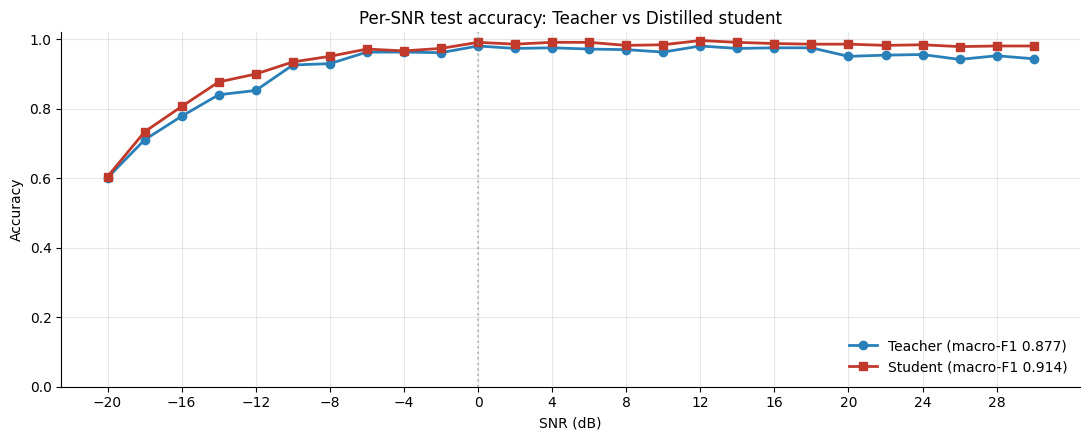


Saved: /content/drive/MyDrive/rf_drones/outputs3/figures3/distillation_comparison.png


In [92]:
import time
import torch
import numpy as np
import matplotlib.pyplot as plt

# ── Headline metrics on the test split ──────────────────────────
model.eval(); student.eval()
t_loss, t_acc, t_f1, t_details = evaluate(model,   test_loader, criterion)
s_loss, s_acc, s_f1, s_details = evaluate(student, test_loader, criterion)

n_t = sum(p.numel() for p in model.parameters())
n_s = sum(p.numel() for p in student.parameters())

# ── Inference latency (median over 50 single-sample forwards) ───
def median_latency_ms(net, n_runs=50):
    net.eval()
    x = torch.randn(1, 2, 128, 128, device=DEVICE)
    with torch.no_grad():
        for _ in range(5): net(x)        # warm-up
        torch.cuda.synchronize()
        times = []
        for _ in range(n_runs):
            torch.cuda.synchronize()
            t0 = time.perf_counter()
            net(x)
            torch.cuda.synchronize()
            times.append((time.perf_counter() - t0) * 1000)
    return float(np.median(times))

lat_t = median_latency_ms(model)
lat_s = median_latency_ms(student)

# ── Side-by-side report ─────────────────────────────────────────
print(f"{'':<28}{'Teacher':>14}{'Student':>14}{'Δ / ratio':>16}")
print("-" * 72)
print(f"{'Test accuracy':<28}{t_acc:>14.4f}{s_acc:>14.4f}{s_acc - t_acc:>+15.4f}")
print(f"{'Test macro-F1':<28}{t_f1:>14.4f}{s_f1:>14.4f}{s_f1 - t_f1:>+15.4f}")
print(f"{'Parameters':<28}{n_t:>14,}{n_s:>14,}{n_s / n_t:>15.1%}")
print(f"{'Size on disk (MB, fp32)':<28}{n_t * 4 / 1e6:>14.1f}{n_s * 4 / 1e6:>14.1f}{(n_s / n_t):>15.1%}")
print(f"{'Latency / sample (ms)':<28}{lat_t:>14.2f}{lat_s:>14.2f}{lat_t / lat_s:>14.1f}x faster")

# ── Per-SNR comparison plot ─────────────────────────────────────
snrs_test  = t_details["snrs"]
preds_t    = t_details["preds"]
preds_s    = s_details["preds"]
labels_arr = t_details["labels"]

unique_snrs = sorted(set(int(s) for s in snrs_test.tolist()))
acc_t_per_snr, acc_s_per_snr = [], []
for s in unique_snrs:
    mask = snrs_test == s
    acc_t_per_snr.append(float((preds_t[mask] == labels_arr[mask]).mean()))
    acc_s_per_snr.append(float((preds_s[mask] == labels_arr[mask]).mean()))

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(unique_snrs, acc_t_per_snr, marker="o", color="#2980b9",
        linewidth=2, label=f"Teacher (macro-F1 {t_f1:.3f})")
ax.plot(unique_snrs, acc_s_per_snr, marker="s", color="#c0392b",
        linewidth=2, label=f"Student (macro-F1 {s_f1:.3f})")
ax.axvline(0, color="#7f8c8d", linestyle=":", alpha=0.5)
ax.set_xlabel("SNR (dB)")
ax.set_ylabel("Accuracy")
ax.set_title("Per-SNR test accuracy: Teacher vs Distilled student")
ax.set_ylim(0, 1.02)
ax.set_xticks(unique_snrs[::2])
ax.grid(alpha=0.3)
ax.legend(loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(FIG_DIR / "distillation_comparison.png", dpi=120)
plt.show()
print(f"\nSaved: {FIG_DIR / 'distillation_comparison.png'}")